In [3]:
import healpy as hp
import numpy as np
import sys
sys.path.append('../')
from scripts.true_cmb import true_cmb
from scripts.gen_sims import gen_sims


In [4]:
cls=true_cmb()
cls.shape

/home/iloveorcas/Internship_Rome/scripts/true_cmb.py:11: UserWarning: Input line 1 contained no data and will not be counted towards `max_rows=382`.  This differs from the behaviour in NumPy <=1.22 which counted lines rather than rows.  If desired, the previous behaviour can be achieved by using `itertools.islice`.
Please see the 1.23 release notes for an example on how to do this.  If you wish to ignore this warning, use `warnings.filterwarnings`.  This warning is expected to be removed in the future and is given only once per `loadtxt` call.
  cl_th = np.loadtxt("https://portal.nersc.gov/project/cmb/pysm-data/pysm_2/camb_lenspotentialCls.dat",skiprows=0, max_rows=382 ,usecols=(1))


(382,)

In [5]:
ells = np.arange(2,cls.size+2)

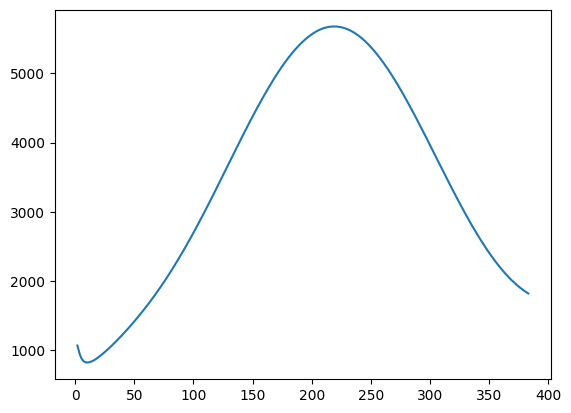

In [6]:
from matplotlib import pyplot as plt
plt.plot(ells,cls)
plt.show()


In [7]:
rcls = []

In [8]:
for i in range(100):
    np.random.seed(i)
    rcls.append(hp.alm2cl(hp.synalm(cls)))

In [9]:
rcls[1]

array([2817.38801539,  980.12039251,  754.56324318,  435.01511673,
       1145.53478057,  908.93581578,  982.699286  ,  786.6474117 ,
        331.99581257,  742.22695133,  723.30270501,  771.16981282,
        650.7883739 ,  956.31942178, 1001.31062954, 1233.78754014,
        575.86179225, 1071.80133727,  746.32322508,  524.40101531,
        708.54503813,  904.35446847,  995.35655808,  948.40771092,
       1377.84062617, 1079.69195647,  888.63870779,  742.87194583,
       1125.30773266,  782.15677047, 1040.40271542, 1305.31372033,
       1180.73074631, 1531.92490808, 1040.56404645,  935.11225912,
       1046.45618951,  893.26093864, 1188.70443714, 1540.12963237,
       1169.82965521, 1391.97571323, 1217.73057197, 1578.10029906,
       1069.23365514, 1382.73722336, 1251.13585749, 1559.11050573,
        936.76967311, 1585.46995592, 1490.3166859 , 1316.36547573,
       1306.91368103, 1745.93456144, 1535.5675214 , 1362.40983987,
       1465.53628813, 1534.206308  , 1634.18166049, 1711.03084

(382,)


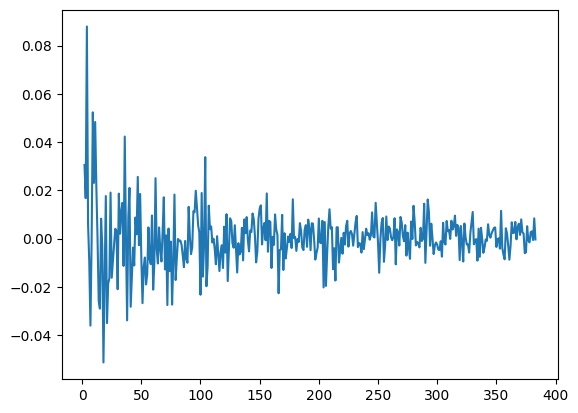

In [10]:
mean_rcls = np.mean(np.array(rcls),axis=0)
#plt.plot(ells,rcls[0])
#plt.plot(ells,rcls[1])
#plt.plot(ells,mean_rcls)
plt.plot(ells,(cls-mean_rcls)/cls)
print(mean_rcls.shape)

In [34]:
def gen_raw_cmb(cl,nsims,nside):
    """Gnere

    Args:
        cl (_type_): _description_
        nsims (_type_): _description_
        nside (_type_): _description_

    Returns:
        _type_: _description_
    """
    cmb_raw=[]
    cl_raw=[]
    npix = hp.nside2npix(nside)
    
    for i in range(nsims):
        np.random.seed(i)
        cl_raw.append(hp.alm2cl(hp.synalm(cl)))
        alm=hp.synalm(cl)
        cmb_raw.append(hp.alm2map(alm, nside))
        
    cmb_raw = np.array(cmb_raw)
    cl_raw = np.array(cl_raw)
    cmb_raw=np.tile(cmb_raw, (1, 7))
    cmb_raw = cmb_raw.reshape(nsims, 7, npix)
    return cmb_raw, cl_raw

THIS CL_RAW IS WRONG

In [35]:
nsims=100
nside=128
cmb_raw,cl_raw=gen_raw_cmb(cls,nsims,nside)

In [36]:
print(cmb_raw.shape)
print(cl_raw.shape)

(100, 7, 196608)
(100, 382)


In [37]:
np.save('cmb_raw.npy',cmb_raw)
np.save('cl_raw.npy',cl_raw)